In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

df=pd.read_csv("C:/Users/jaine/Downloads/Fraud.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [18]:
df.isnull().sum()


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['type'].value_counts()


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [21]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [22]:
df.drop(['nameOrig','nameDest'], axis=1, inplace=True)

<Axes: >

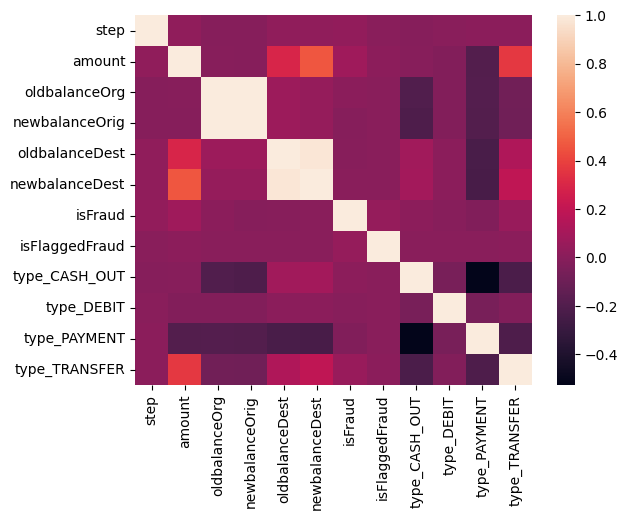

In [23]:
sns.heatmap(df.corr())

<Axes: ylabel='amount'>

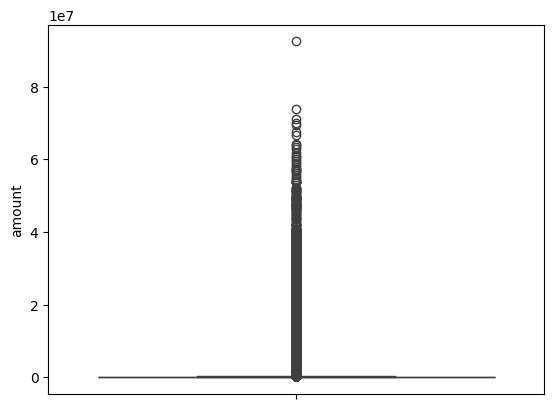

In [24]:
sns.boxplot(df['amount'])



In [25]:
print(df.columns)

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')


In [26]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,0,False,False,True,False
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,0,False,False,True,False
2,1,181.00,181.00,0.00,0.00,0.00,1,0,False,False,False,True
3,1,181.00,181.00,0.00,21182.00,0.00,1,0,True,False,False,False
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,0,True,False,False,False
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,0,False,False,False,True
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,True,False,False,False
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,0,False,False,False,True


In [27]:
df = df.astype(int)
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839,170136,160296,0,0,0,0,0,0,1,0
1,1,1864,21249,19384,0,0,0,0,0,0,1,0
2,1,181,181,0,0,0,1,0,0,0,0,1
3,1,181,181,0,21182,0,1,0,1,0,0,0
4,1,11668,41554,29885,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682,339682,0,0,339682,1,0,1,0,0,0
6362616,743,6311409,6311409,0,0,0,1,0,0,0,0,1
6362617,743,6311409,6311409,0,68488,6379898,1,0,1,0,0,0
6362618,743,850002,850002,0,0,0,1,0,0,0,0,1


Q3. Variable Selection

The variables were selected based on data understanding, correlation analysis, and feature importance. Identifier columns such as ‘nameOrig’ and ‘nameDest’ were removed as they do not contribute to prediction. The categorical variable ‘type’ was encoded using one-hot encoding. Features related to transaction amount and account balances were retained as they are logically important for detecting fraudulent behavior.

In [28]:
X=df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","type_CASH_OUT","type_DEBIT","type_PAYMENT","type_TRANSFER"]]
y=df["isFraud"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1) 
model=RandomForestClassifier()
model.fit(X_train,y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
predict=model.predict(X_test)
print(predict)

[0 0 0 ... 0 0 0]


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270877
           1       0.97      0.79      0.87      1647

    accuracy                           1.00   1272524
   macro avg       0.98      0.89      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



Or Another Trick

In [32]:
accuracy = accuracy_score(y_test, predict)
print("Accuracy:", accuracy)

Accuracy: 0.9996943083195288


In [33]:
precision = precision_score(y_test, predict)
print("Precision:", precision)

Precision: 0.9701046337817638


In [34]:
recall = recall_score(y_test, predict)
print("Recall:", recall)

Recall: 0.7880995749848209


In [35]:
f1 = f1_score(y_test, predict)
print("F1 Score:", f1)

F1 Score: 0.8696817420435511


The model performance was evaluated using accuracy, precision, recall, and F1-score. Recall was given higher importance as it reflects the model’s ability to correctly identify fraudulent transactions.

Q5:
Feature importance analysis revealed that transaction amount, account balances (oldbalanceOrg and newbalanceOrig), and transaction type (especially TRANSFER and CASH_OUT) are the most significant factors in predicting fraudulent transactions. These features capture abnormal transaction patterns such as high transaction values and sudden changes in account balances

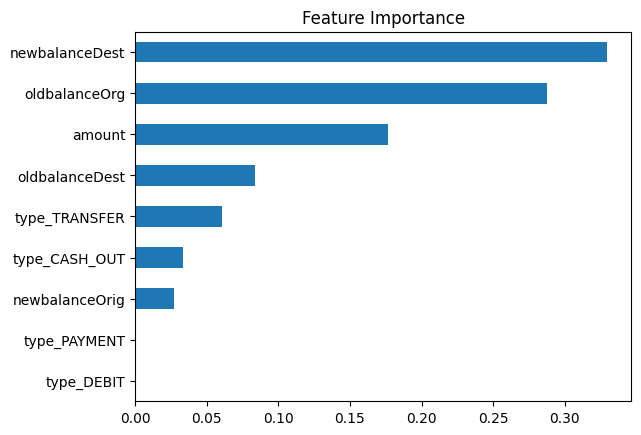

In [36]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)
import matplotlib.pyplot as plt

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Q6:
Yes, these factors make logical sense. Fraudulent transactions often involve unusually high amounts and sudden changes in account balances. Additionally, certain transaction types such as TRANSFER and CASH_OUT are more prone to fraud. Therefore, the model’s identified features align well with real-world fraud patterns

Q7:
To prevent fraudulent transactions, the company should implement real-time monitoring systems that can detect suspicious activities instantly. Multi-factor authentication such as OTP verification should be used for high-value transactions. Additionally, transaction limits and anomaly detection systems can help reduce fraud. Machine learning-based fraud detection models should be continuously updated to adapt to new fraud patterns

Q8:
The effectiveness of the implemented fraud detection system can be evaluated by monitoring key performance metrics such as reduction in fraud losses, improvement in recall and precision, and decrease in false positives. Continuous monitoring and periodic model evaluation should be conducted to ensure that the system is effectively identifying fraudulent transactions